# eHarvest — Demand & Supply Quantity Forecasting

**What this notebook does:**  
Trains two separate sets of Prophet models — one for **demand** (quantity demanded per commodity)  
and one for **supply** (quantity supplied per commodity).  
Outputs a gap analysis showing predicted shortages or surpluses.

**This is different from `training_synthetic.ipynb`** which only forecasts *prices*.  
This notebook forecasts *quantities*.

**Input files:**
- `synthetic_data/demand_records.csv`
- `synthetic_data/supply_records.csv`

**Output artefacts:**
- `demand_models.pkl` — one Prophet model per commodity (quantity demanded)
- `supply_models.pkl` — one Prophet model per commodity (quantity supplied)
- `demand_features.pkl` — region regressor columns per commodity
- `supply_features.pkl` — region regressor columns per commodity
- `demand_commodity_list.pkl` — sorted list of demand commodity names
- `supply_commodity_list.pkl` — sorted list of supply commodity names
- `demand_training_data.pkl` — demand training DataFrames
- `supply_training_data.pkl` — supply training DataFrames

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

c:\Users\munashe\Projects\eharvest-main\eharvest_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Libraries loaded.


## Cell 2 — Load Data

In [5]:
demand_df = pd.read_csv('demand_records.csv')
supply_df = pd.read_csv('supply_data.csv')

print('=== DEMAND ===')
print(f'Shape:              {demand_df.shape}')
print(f'Columns:            {demand_df.columns.tolist()}')
print(f'Date range:         {demand_df["date"].min()}  →  {demand_df["date"].max()}')
print(f'Unique commodities: {demand_df["commodity"].nunique()}')
print(f'Unique regions:     {demand_df["region"].nunique()}')
print(f'Null counts:\n{demand_df.isnull().sum()}')

print('\n=== SUPPLY ===')
print(f'Shape:              {supply_df.shape}')
print(f'Columns:            {supply_df.columns.tolist()}')
print(f'Date range:         {supply_df["date"].min()}  →  {supply_df["date"].max()}')
print(f'Unique commodities: {supply_df["commodity"].nunique()}')
print(f'Unique regions:     {supply_df["region"].nunique()}')
print(f'Null counts:\n{supply_df.isnull().sum()}')

=== DEMAND ===
Shape:              (1000000, 6)
Columns:            ['date', 'commodity', 'region', 'quantity', 'buyer_type', 'season']
Date range:         2022-01-01  →  2026-05-22
Unique commodities: 39
Unique regions:     10
Null counts:
date          0
commodity     0
region        0
quantity      0
buyer_type    0
season        0
dtype: int64

=== SUPPLY ===
Shape:              (1000000, 6)
Columns:            ['date', 'commodity', 'region', 'quantity_kg', 'supplier_type', 'season']
Date range:         2022-01-01  →  2026-05-22
Unique commodities: 39
Unique regions:     10
Null counts:
date             0
commodity        0
region           0
quantity_kg      0
supplier_type    0
season           0
dtype: int64


## Cell 3 — Data Quality Audit

Key things to check:
- Are any quantities zero or negative?
- Do both tables cover the same commodities?
- Are the date ranges aligned?

In [6]:
print('=== DEMAND quantity statistics ===')
print(demand_df['quantity'].describe())
print(f'Zero/null quantities: {(demand_df["quantity"].isnull() | (demand_df["quantity"] <= 0)).sum()}')

print('\n=== SUPPLY quantity_kg statistics ===')
print(supply_df['quantity_kg'].describe())
print(f'Zero/null quantities: {(supply_df["quantity_kg"].isnull() | (supply_df["quantity_kg"] <= 0)).sum()}')

# Commodity alignment check
demand_commodities = set(demand_df['commodity'].unique())
supply_commodities = set(supply_df['commodity'].unique())

only_in_demand = demand_commodities - supply_commodities
only_in_supply = supply_commodities - demand_commodities
in_both        = demand_commodities & supply_commodities

print(f'\n=== Commodity alignment ===')
print(f'In both demand & supply: {len(in_both)}')
print(f'Only in demand (no supply data): {only_in_demand}')
print(f'Only in supply (no demand data): {only_in_supply}')

# Season distribution
print(f'\n=== Season distribution (demand) ===')
print(demand_df['season'].value_counts())

print(f'\n=== Buyer type distribution ===')
print(demand_df['buyer_type'].value_counts())

print(f'\n=== Supplier type distribution ===')
print(supply_df['supplier_type'].value_counts())

=== DEMAND quantity statistics ===
count    1000000.000000
mean       10494.197813
std        14316.762400
min            5.000000
25%          149.900000
50%         2329.900000
75%        13753.200000
max        50000.000000
Name: quantity, dtype: float64
Zero/null quantities: 0

=== SUPPLY quantity_kg statistics ===
count    1000000.000000
mean       44080.524542
std        46535.028526
min           50.100000
25%         6829.000000
50%        21847.650000
75%        70206.750000
max       299998.500000
Name: quantity_kg, dtype: float64
Zero/null quantities: 0

=== Commodity alignment ===
In both demand & supply: 39
Only in demand (no supply data): set()
Only in supply (no demand data): set()

=== Season distribution (demand) ===
season
summer         527620
harvest/dry    472380
Name: count, dtype: int64

=== Buyer type distribution ===
buyer_type
Wholesaler                     250344
Household                      250191
Institutional (GMB/Milling)    249882
Retailer / Vendor    

## Cell 4 — Preprocess Demand Data

Key differences from price preprocessing:
- Target variable is `quantity` (units sold), not price
- Aggregation uses **sum** not mean — total quantity demanded per month, not average
- `seasonality_mode='additive'` is better for quantities — demand shifts by a fixed
  amount each season rather than scaling proportionally the way prices do

In [7]:
demand_df['ds'] = pd.to_datetime(demand_df['date'])
demand_df['y']  = demand_df['quantity']

print(f'Columns at start: {demand_df.columns.tolist()}')
assert 'commodity' in demand_df.columns, "ERROR: 'commodity' column missing"
assert 'region'    in demand_df.columns, "ERROR: 'region' column missing"

# --- Step 1: Drop zero / null quantities ---
before = len(demand_df)
demand_df = demand_df[demand_df['y'].notna() & (demand_df['y'] > 0)].copy()
print(f'Dropped bad quantities: {before - len(demand_df):,} rows. Remaining: {len(demand_df):,}')

# --- Step 2: Per-commodity outlier removal ---
chunks = []
for commodity, group in demand_df.groupby('commodity'):
    Q1    = group['y'].quantile(0.05)
    Q3    = group['y'].quantile(0.95)
    IQR   = Q3 - Q1
    lower = max(0.0, Q1 - 3 * IQR)
    upper = Q3 + 3 * IQR
    chunks.append(group[(group['y'] >= lower) & (group['y'] <= upper)])

before = len(demand_df)
demand_df = pd.concat(chunks, ignore_index=True)
print(f'Removed demand outliers: {before - len(demand_df):,} rows. Remaining: {len(demand_df):,}')

# --- Step 3: Aggregate to monthly TOTAL per commodity + region ---
# SUM not mean — we want total quantity demanded that month, not average per record
demand_df['ds_month'] = demand_df['ds'].dt.to_period('M').dt.to_timestamp()
demand_agg = (
    demand_df.groupby(['ds_month', 'commodity', 'region'])['y']
    .sum()
    .reset_index()
    .rename(columns={'ds_month': 'ds'})
)

print(f'\nDemand aggregated shape:   {demand_agg.shape}')
print(f'Unique commodities:        {demand_agg["commodity"].nunique()}')
print(f'Date range:                {demand_agg["ds"].min()}  →  {demand_agg["ds"].max()}')
demand_agg.head()

Columns at start: ['date', 'commodity', 'region', 'quantity', 'buyer_type', 'season', 'ds', 'y']
Dropped bad quantities: 0 rows. Remaining: 1,000,000
Removed demand outliers: 0 rows. Remaining: 1,000,000

Demand aggregated shape:   (20670, 4)
Unique commodities:        39
Date range:                2022-01-01 00:00:00  →  2026-05-01 00:00:00


,ds,commodity,region,y
0,2022-01-01,Avocados,Bulawayo,256656.6
1,2022-01-01,Avocados,Harare,455346.6
2,2022-01-01,Avocados,Manicaland,497033.5
3,2022-01-01,Avocados,Mashonaland Central,864466.9
4,2022-01-01,Avocados,Mashonaland East,563896.4


## Cell 5 — Preprocess Supply Data

In [8]:
supply_df['ds'] = pd.to_datetime(supply_df['date'])
supply_df['y']  = supply_df['quantity_kg']     # supply uses quantity_kg column

print(f'Columns at start: {supply_df.columns.tolist()}')
assert 'commodity' in supply_df.columns, "ERROR: 'commodity' column missing"
assert 'region'    in supply_df.columns, "ERROR: 'region' column missing"

# --- Step 1: Drop zero / null quantities ---
before = len(supply_df)
supply_df = supply_df[supply_df['y'].notna() & (supply_df['y'] > 0)].copy()
print(f'Dropped bad quantities: {before - len(supply_df):,} rows. Remaining: {len(supply_df):,}')

# --- Step 2: Per-commodity outlier removal ---
chunks = []
for commodity, group in supply_df.groupby('commodity'):
    Q1    = group['y'].quantile(0.05)
    Q3    = group['y'].quantile(0.95)
    IQR   = Q3 - Q1
    lower = max(0.0, Q1 - 3 * IQR)
    upper = Q3 + 3 * IQR
    chunks.append(group[(group['y'] >= lower) & (group['y'] <= upper)])

before = len(supply_df)
supply_df = pd.concat(chunks, ignore_index=True)
print(f'Removed supply outliers: {before - len(supply_df):,} rows. Remaining: {len(supply_df):,}')

# --- Step 3: Aggregate to monthly TOTAL per commodity + region ---
supply_df['ds_month'] = supply_df['ds'].dt.to_period('M').dt.to_timestamp()
supply_agg = (
    supply_df.groupby(['ds_month', 'commodity', 'region'])['y']
    .sum()
    .reset_index()
    .rename(columns={'ds_month': 'ds'})
)

print(f'\nSupply aggregated shape:   {supply_agg.shape}')
print(f'Unique commodities:        {supply_agg["commodity"].nunique()}')
print(f'Date range:                {supply_agg["ds"].min()}  →  {supply_agg["ds"].max()}')
supply_agg.head()

Columns at start: ['date', 'commodity', 'region', 'quantity_kg', 'supplier_type', 'season', 'ds', 'y']
Dropped bad quantities: 0 rows. Remaining: 1,000,000
Removed supply outliers: 0 rows. Remaining: 1,000,000

Supply aggregated shape:   (20670, 4)
Unique commodities:        39
Date range:                2022-01-01 00:00:00  →  2026-05-01 00:00:00


,ds,commodity,region,y
0,2022-01-01,Avocados,Bulawayo,2505319.8
1,2022-01-01,Avocados,Harare,1628752.7
2,2022-01-01,Avocados,Manicaland,1909837.3
3,2022-01-01,Avocados,Mashonaland Central,2894669.5
4,2022-01-01,Avocados,Mashonaland East,2061366.4


## Cell 6 — Training Helpers

Same structure as the price notebook but with two key differences:
- `seasonality_mode='additive'` — quantity demand shifts by a fixed seasonal amount, it doesn't scale
- `changepoint_prior_scale=0.15` — slightly more flexible for quantities which can shift more abruptly than prices

In [9]:
def build_training_frame(commodity_name, df_agg):
    """
    Build the Prophet-ready DataFrame for a single commodity.
    Returns (df_prophet, region_cols).
    """
    subset = df_agg[df_agg['commodity'] == commodity_name].copy()
    has_multiple_regions = subset['region'].nunique() > 1

    if has_multiple_regions:
        region_dummies = pd.get_dummies(subset['region'], prefix='region').astype(int)
        region_cols    = region_dummies.columns.tolist()
        df_prophet     = pd.concat(
            [subset[['ds', 'y']].reset_index(drop=True),
             region_dummies.reset_index(drop=True)],
            axis=1
        )
    else:
        region_cols = []
        df_prophet  = subset[['ds', 'y']].copy()

    return df_prophet, region_cols


def train_model(commodity_name, df_agg, model_type='demand', min_samples=24):
    """
    Train a Prophet model for one commodity.

    Args:
        commodity_name (str)  : commodity to train
        df_agg         (DataFrame): aggregated monthly data with ds, y, region
        model_type     (str)  : 'demand' or 'supply' — for logging only
        min_samples    (int)  : skip commodities with fewer samples than this

    Returns:
        model, region_cols, df_prophet  (all None if skipped)
    """
    df_prophet, region_cols = build_training_frame(commodity_name, df_agg)

    if len(df_prophet) < min_samples:
        print(f'  ⚠  [{model_type}] Skipping "{commodity_name}" — '
              f'{len(df_prophet)} samples < {min_samples} minimum')
        return None, None, None

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        # Additive for quantities: demand for Maize increases by +5000 kg in
        # harvest season, it doesn't multiply by 1.3x the way prices do
        seasonality_mode='additive',
        changepoint_prior_scale=0.15,
    )

    for col in region_cols:
        model.add_regressor(col)

    model.fit(df_prophet)
    return model, region_cols, df_prophet


print('Training helpers defined.')

Training helpers defined.


## Cell 7 — Train Demand Models

In [10]:
demand_models        = {}
demand_feature_cols  = {}
demand_training_data = {}
demand_skipped       = []

demand_commodities = sorted(demand_agg['commodity'].unique())
print(f'Training DEMAND models for {len(demand_commodities)} commodities...\n')

for i, commodity in enumerate(demand_commodities, 1):
    print(f'[{i:>3}/{len(demand_commodities)}] {commodity}')
    model, cols, df_train = train_model(commodity, demand_agg, model_type='demand')

    if model is not None:
        demand_models[commodity]        = model
        demand_feature_cols[commodity]  = cols
        demand_training_data[commodity] = df_train
    else:
        demand_skipped.append(commodity)

print(f'\n✅ Demand trained:  {len(demand_models)} models')
print(f'⚠  Demand skipped:  {demand_skipped}')

13:25:13 - cmdstanpy - INFO - Chain [1] start processing


Training DEMAND models for 39 commodities...

[  1/39] Avocados


13:25:13 - cmdstanpy - INFO - Chain [1] done processing
13:25:13 - cmdstanpy - INFO - Chain [1] start processing
13:25:13 - cmdstanpy - INFO - Chain [1] done processing


[  2/39] Bananas


13:25:13 - cmdstanpy - INFO - Chain [1] start processing


...

[ 37/39] Sweet potatoes


13:25:21 - cmdstanpy - INFO - Chain [1] start processing


[ 38/39] Tomatoes


13:25:21 - cmdstanpy - INFO - Chain [1] done processing
13:25:21 - cmdstanpy - INFO - Chain [1] start processing
13:25:21 - cmdstanpy - INFO - Chain [1] done processing


[ 39/39] Wheat

✅ Demand trained:  39 models
⚠  Demand skipped:  []


## Cell 8 — Train Supply Models

In [11]:
supply_models        = {}
supply_feature_cols  = {}
supply_training_data = {}
supply_skipped       = []

supply_commodities = sorted(supply_agg['commodity'].unique())
print(f'Training SUPPLY models for {len(supply_commodities)} commodities...\n')

for i, commodity in enumerate(supply_commodities, 1):
    print(f'[{i:>3}/{len(supply_commodities)}] {commodity}')
    model, cols, df_train = train_model(commodity, supply_agg, model_type='supply')

    if model is not None:
        supply_models[commodity]        = model
        supply_feature_cols[commodity]  = cols
        supply_training_data[commodity] = df_train
    else:
        supply_skipped.append(commodity)

print(f'\n✅ Supply trained:  {len(supply_models)} models')
print(f'⚠  Supply skipped:  {supply_skipped}')

13:26:33 - cmdstanpy - INFO - Chain [1] start processing


Training SUPPLY models for 39 commodities...

[  1/39] Avocados


13:26:33 - cmdstanpy - INFO - Chain [1] done processing
13:26:34 - cmdstanpy - INFO - Chain [1] start processing


[  2/39] Bananas


13:26:34 - cmdstanpy - INFO - Chain [1] done processing
13:26:34 - cmdstanpy - INFO - Chain [1] start processing


...

[ 38/39] Tomatoes


13:26:42 - cmdstanpy - INFO - Chain [1] done processing
13:26:42 - cmdstanpy - INFO - Chain [1] start processing


[ 39/39] Wheat


13:26:42 - cmdstanpy - INFO - Chain [1] done processing



✅ Supply trained:  39 models
⚠  Supply skipped:  []


## Cell 9 — Cross-Validation

Runs CV on key commodities for both demand and supply models.  
Set `cv_all = True` to validate every model (slow — allow 10–20 minutes).

In [12]:
cv_all = False

KEY_COMMODITIES = [
    'Maize', 'Maize meal (roller)', 'Beans (sugar)', 'Tomatoes',
    'Onions', 'Carrots', 'Oil (vegetable)', 'Beef', 'Salt', 'Sugar',
]


def run_cv(models_dict, training_data_dict, label, key_commodities, cv_all=False):
    targets = list(models_dict.keys()) if cv_all else [
        c for c in key_commodities if c in models_dict
    ]

    results = {}
    header  = f'{"Commodity":<30}  {"MAPE":>8}  {"RMSE":>12}  {"Assessment":>14}'
    print(f'--- {label} CV ({len(targets)} commodities) ---')
    print(header)
    print('-' * 72)

    for commodity in targets:
        td           = training_data_dict[commodity]
        date_range   = (td['ds'].max() - td['ds'].min()).days
        initial_days = min(730, int(date_range * 0.6))

        if len(td) < 30:
            print(f'{commodity:<30}  {"SKIPPED (< 30 samples)":>38}')
            continue

        try:
            df_cv   = cross_validation(
                models_dict[commodity],
                initial=f'{initial_days} days',
                period='90 days',
                horizon='180 days',
                disable_tqdm=True,
            )
            metrics = performance_metrics(df_cv)
            results[commodity] = metrics

            mape       = metrics['mape'].mean()
            rmse       = metrics['rmse'].mean()
            assessment = '✅ Good' if mape < 0.15 else ('⚠  Acceptable' if mape < 0.30 else '❌ Poor')
            print(f'{commodity:<30}  {mape:>7.2%}  {rmse:>12.1f}  {assessment:>14}')

        except Exception as e:
            print(f'{commodity:<30}  CV failed: {e}')

    print()
    return results


print('Running cross-validation...\n')
demand_cv_results = run_cv(demand_models, demand_training_data, 'DEMAND', KEY_COMMODITIES, cv_all)
supply_cv_results = run_cv(supply_models, supply_training_data, 'SUPPLY', KEY_COMMODITIES, cv_all)
print('Cross-validation complete.')

13:26:52 - cmdstanpy - INFO - Chain [1] start processing


Running cross-validation...

--- DEMAND CV (9 commodities) ---
Commodity                           MAPE          RMSE      Assessment
------------------------------------------------------------------------


13:26:52 - cmdstanpy - INFO - Chain [1] done processing
13:26:52 - cmdstanpy - INFO - Chain [1] start processing
13:26:52 - cmdstanpy - INFO - Chain [1] done processing
13:26:53 - cmdstanpy - INFO - Chain [1] start processing
13:26:53 - cmdstanpy - INFO - Chain [1] done processing
13:26:53 - cmdstanpy - INFO - Chain [1] start processing
13:26:53 - cmdstanpy - INFO - Chain [1] done processing
13:26:53 - cmdstanpy - INFO - Chain [1] start processing
13:26:53 - cmdstanpy - INFO - Chain [1] done processing
13:26:53 - cmdstanpy - INFO - Chain [1] start processing
13:26:53 - cmdstanpy - INFO - Chain [1] done processing
13:26:54 - cmdstanpy - INFO - Chain [1] start processing
13:26:54 - cmdstanpy - INFO - Chain [1] done processing
13:26:54 - cmdstanpy - INFO - Chain [1] start processing
13:26:54 - cmdstanpy - INFO - Chain [1] done processing
13:26:54 - cmdstanpy - INFO - Chain [1] start processing
13:26:54 - cmdstanpy - INFO - Chain [1] done processing


Maize                            21.42%      130341.0   ⚠  Acceptable


13:26:54 - cmdstanpy - INFO - Chain [1] start processing
13:26:55 - cmdstanpy - INFO - Chain [1] done processing
13:26:55 - cmdstanpy - INFO - Chain [1] start processing
13:26:55 - cmdstanpy - INFO - Chain [1] done processing
13:26:55 - cmdstanpy - INFO - Chain [1] start processing
13:26:55 - cmdstanpy - INFO - Chain [1] done processing
13:26:55 - cmdstanpy - INFO - Chain [1] start processing
13:26:55 - cmdstanpy - INFO - Chain [1] done processing
13:26:55 - cmdstanpy - INFO - Chain [1] start processing
13:26:55 - cmdstanpy - INFO - Chain [1] done processing
13:26:56 - cmdstanpy - INFO - Chain [1] start processing
13:26:56 - cmdstanpy - INFO - Chain [1] done processing
13:26:56 - cmdstanpy - INFO - Chain [1] start processing
13:26:56 - cmdstanpy - INFO - Chain [1] done processing
13:26:56 - cmdstanpy - INFO - Chain [1] start processing
13:26:56 - cmdstanpy - INFO - Chain [1] done processing


...

Beef                             19.07%      515158.9   ⚠  Acceptable


13:27:25 - cmdstanpy - INFO - Chain [1] done processing
13:27:26 - cmdstanpy - INFO - Chain [1] start processing
13:27:26 - cmdstanpy - INFO - Chain [1] done processing
13:27:26 - cmdstanpy - INFO - Chain [1] start processing
13:27:26 - cmdstanpy - INFO - Chain [1] done processing
13:27:26 - cmdstanpy - INFO - Chain [1] start processing
13:27:26 - cmdstanpy - INFO - Chain [1] done processing
13:27:26 - cmdstanpy - INFO - Chain [1] start processing
13:27:26 - cmdstanpy - INFO - Chain [1] done processing
13:27:27 - cmdstanpy - INFO - Chain [1] start processing
13:27:27 - cmdstanpy - INFO - Chain [1] done processing
13:27:27 - cmdstanpy - INFO - Chain [1] start processing
13:27:27 - cmdstanpy - INFO - Chain [1] done processing
13:27:27 - cmdstanpy - INFO - Chain [1] start processing
13:27:27 - cmdstanpy - INFO - Chain [1] done processing
13:27:27 - cmdstanpy - INFO - Chain [1] start processing
13:27:27 - cmdstanpy - INFO - Chain [1] done processing


Salt                             19.33%       65306.7   ⚠  Acceptable


13:27:28 - cmdstanpy - INFO - Chain [1] start processing
13:27:28 - cmdstanpy - INFO - Chain [1] done processing
13:27:28 - cmdstanpy - INFO - Chain [1] start processing
13:27:28 - cmdstanpy - INFO - Chain [1] done processing
13:27:28 - cmdstanpy - INFO - Chain [1] start processing
13:27:28 - cmdstanpy - INFO - Chain [1] done processing
13:27:28 - cmdstanpy - INFO - Chain [1] start processing
13:27:28 - cmdstanpy - INFO - Chain [1] done processing
13:27:29 - cmdstanpy - INFO - Chain [1] start processing
13:27:29 - cmdstanpy - INFO - Chain [1] done processing
13:27:29 - cmdstanpy - INFO - Chain [1] start processing
13:27:29 - cmdstanpy - INFO - Chain [1] done processing
13:27:29 - cmdstanpy - INFO - Chain [1] start processing
13:27:29 - cmdstanpy - INFO - Chain [1] done processing


Sugar                            19.96%      524352.4   ⚠  Acceptable

Cross-validation complete.


## Cell 10 — Save All Artefacts

In [13]:
demand_commodity_list = sorted(list(demand_models.keys()))
supply_commodity_list = sorted(list(supply_models.keys()))

joblib.dump(demand_models,          'demand_models.pkl')
joblib.dump(demand_feature_cols,    'demand_features.pkl')
joblib.dump(demand_training_data,   'demand_training_data.pkl')
joblib.dump(demand_commodity_list,  'demand_commodity_list.pkl')

joblib.dump(supply_models,          'supply_models.pkl')
joblib.dump(supply_feature_cols,    'supply_features.pkl')
joblib.dump(supply_training_data,   'supply_training_data.pkl')
joblib.dump(supply_commodity_list,  'supply_commodity_list.pkl')

print('✅ Saved demand artefacts:')
print(f'  demand_models.pkl           ({len(demand_models)} models)')
print(f'  demand_features.pkl')
print(f'  demand_training_data.pkl')
print(f'  demand_commodity_list.pkl   ({len(demand_commodity_list)} commodities)')

print('\n✅ Saved supply artefacts:')
print(f'  supply_models.pkl           ({len(supply_models)} models)')
print(f'  supply_features.pkl')
print(f'  supply_training_data.pkl')
print(f'  supply_commodity_list.pkl   ({len(supply_commodity_list)} commodities)')

# Commodities that have BOTH demand and supply models — these support gap analysis
both = sorted(set(demand_commodity_list) & set(supply_commodity_list))
print(f'\nCommodities with both demand AND supply models: {len(both)}')
for c in both:
    print(f'  {c}')

✅ Saved demand artefacts:
  demand_models.pkl           (39 models)
  demand_features.pkl
  demand_training_data.pkl
  demand_commodity_list.pkl   (39 commodities)

✅ Saved supply artefacts:
  supply_models.pkl           (39 models)
  supply_features.pkl
  supply_training_data.pkl
  supply_commodity_list.pkl   (39 commodities)

Commodities with both demand AND supply models: 39
  Avocados
  Bananas
  Barley
  Beans (round)
  Beans (sugar)
  Beef
  Butternuts
  Cabbages
  Carrots
  Chicken
  Cooking oil (sunflower)
  Cowpeas
  Cucumber
  Eggs (tray of 30)
  Fish (kapenta)
  Flour (wheat)
  Garlic
  Green pepper
  Groundnuts (shelled)
  Irish potatoes
  Maize
  Maize meal
  Mangoes
  Millet (finger millet)
  Oil (vegetable)
  Okra (derere)
  Onions
  Oranges
  Pigeon peas
  Pumpkin
  Rice
  Salt
  Sorghum
  Soybeans
  Spinach (rape)
  Sugar
  Sweet potatoes
  Tomatoes
  Wheat


## Cell 11 — Inference Helpers

Two functions:
- `forecast_demand()` — predicts quantity demanded
- `forecast_supply()` — predicts quantity supplied
- `forecast_gap()` — runs both and returns shortage / surplus analysis

In [14]:
def _forecast_quantity(commodity_name, models_dict, feature_cols_dict,
                        region=None, periods=12, freq='MS'):
    """
    Internal helper — generates a quantity forecast using the given model dict.
    Used by both forecast_demand() and forecast_supply().
    """
    if commodity_name not in models_dict:
        raise ValueError(
            f"No model for '{commodity_name}'.\n"
            f"Available: {sorted(list(models_dict.keys()))}"
        )
    if not (1 <= periods <= 60):
        raise ValueError('periods must be between 1 and 60.')

    model  = models_dict[commodity_name]
    cols   = feature_cols_dict[commodity_name]
    future = model.make_future_dataframe(periods=periods, freq=freq)

    if cols:
        for col in cols:
            future[col] = 0
        if region is not None:
            rc = f'region_{region}'
            if rc not in cols:
                available = sorted([c.replace('region_', '') for c in cols])
                raise ValueError(
                    f"Region '{region}' not found for '{commodity_name}'.\n"
                    f"Available: {available}"
                )
            future[rc] = 1

    forecast = model.predict(future)
    result   = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods).copy()
    result[['yhat', 'yhat_lower', 'yhat_upper']] = (
        result[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0).round(1)
    )
    result['commodity'] = commodity_name
    result['region']    = region or 'National'
    return result.reset_index(drop=True)


def forecast_demand(commodity_name, region=None, periods=12):
    """Forecast quantity demanded (kg/units) for a commodity."""
    result = _forecast_quantity(
        commodity_name, demand_models, demand_feature_cols, region, periods
    )
    result = result.rename(columns={
        'yhat': 'demand', 'yhat_lower': 'demand_lower', 'yhat_upper': 'demand_upper'
    })
    return result


def forecast_supply(commodity_name, region=None, periods=12):
    """Forecast quantity supplied (kg/units) for a commodity."""
    result = _forecast_quantity(
        commodity_name, supply_models, supply_feature_cols, region, periods
    )
    result = result.rename(columns={
        'yhat': 'supply', 'yhat_lower': 'supply_lower', 'yhat_upper': 'supply_upper'
    })
    return result


def forecast_gap(commodity_name, region=None, periods=12):
    """
    Combines demand and supply forecasts into a gap analysis.

    gap = supply - demand
      positive → surplus  (supply exceeds demand)
      negative → shortage (demand exceeds supply)

    Returns a DataFrame with columns:
      ds, demand, supply, gap, gap_pct, status
    """
    if commodity_name not in demand_models:
        raise ValueError(f"No demand model for '{commodity_name}'")
    if commodity_name not in supply_models:
        raise ValueError(f"No supply model for '{commodity_name}'")

    d = forecast_demand(commodity_name, region, periods)[['ds', 'demand', 'demand_lower', 'demand_upper']]
    s = forecast_supply(commodity_name, region, periods)[['ds', 'supply', 'supply_lower', 'supply_upper']]

    gap_df = d.merge(s, on='ds')
    gap_df['gap']     = (gap_df['supply'] - gap_df['demand']).round(1)
    gap_df['gap_pct'] = np.where(
        gap_df['demand'] > 0,
        ((gap_df['supply'] - gap_df['demand']) / gap_df['demand'] * 100).round(1),
        0.0
    )
    gap_df['status'] = gap_df['gap'].apply(
        lambda g: 'SURPLUS' if g > 0 else ('SHORTAGE' if g < 0 else 'BALANCED')
    )
    gap_df['commodity'] = commodity_name
    gap_df['region']    = region or 'National'

    return gap_df.reset_index(drop=True)


print('forecast_demand(), forecast_supply(), forecast_gap() ready.')

forecast_demand(), forecast_supply(), forecast_gap() ready.


## Cell 12 — Demand vs Supply Plots (Visual Sanity Check)

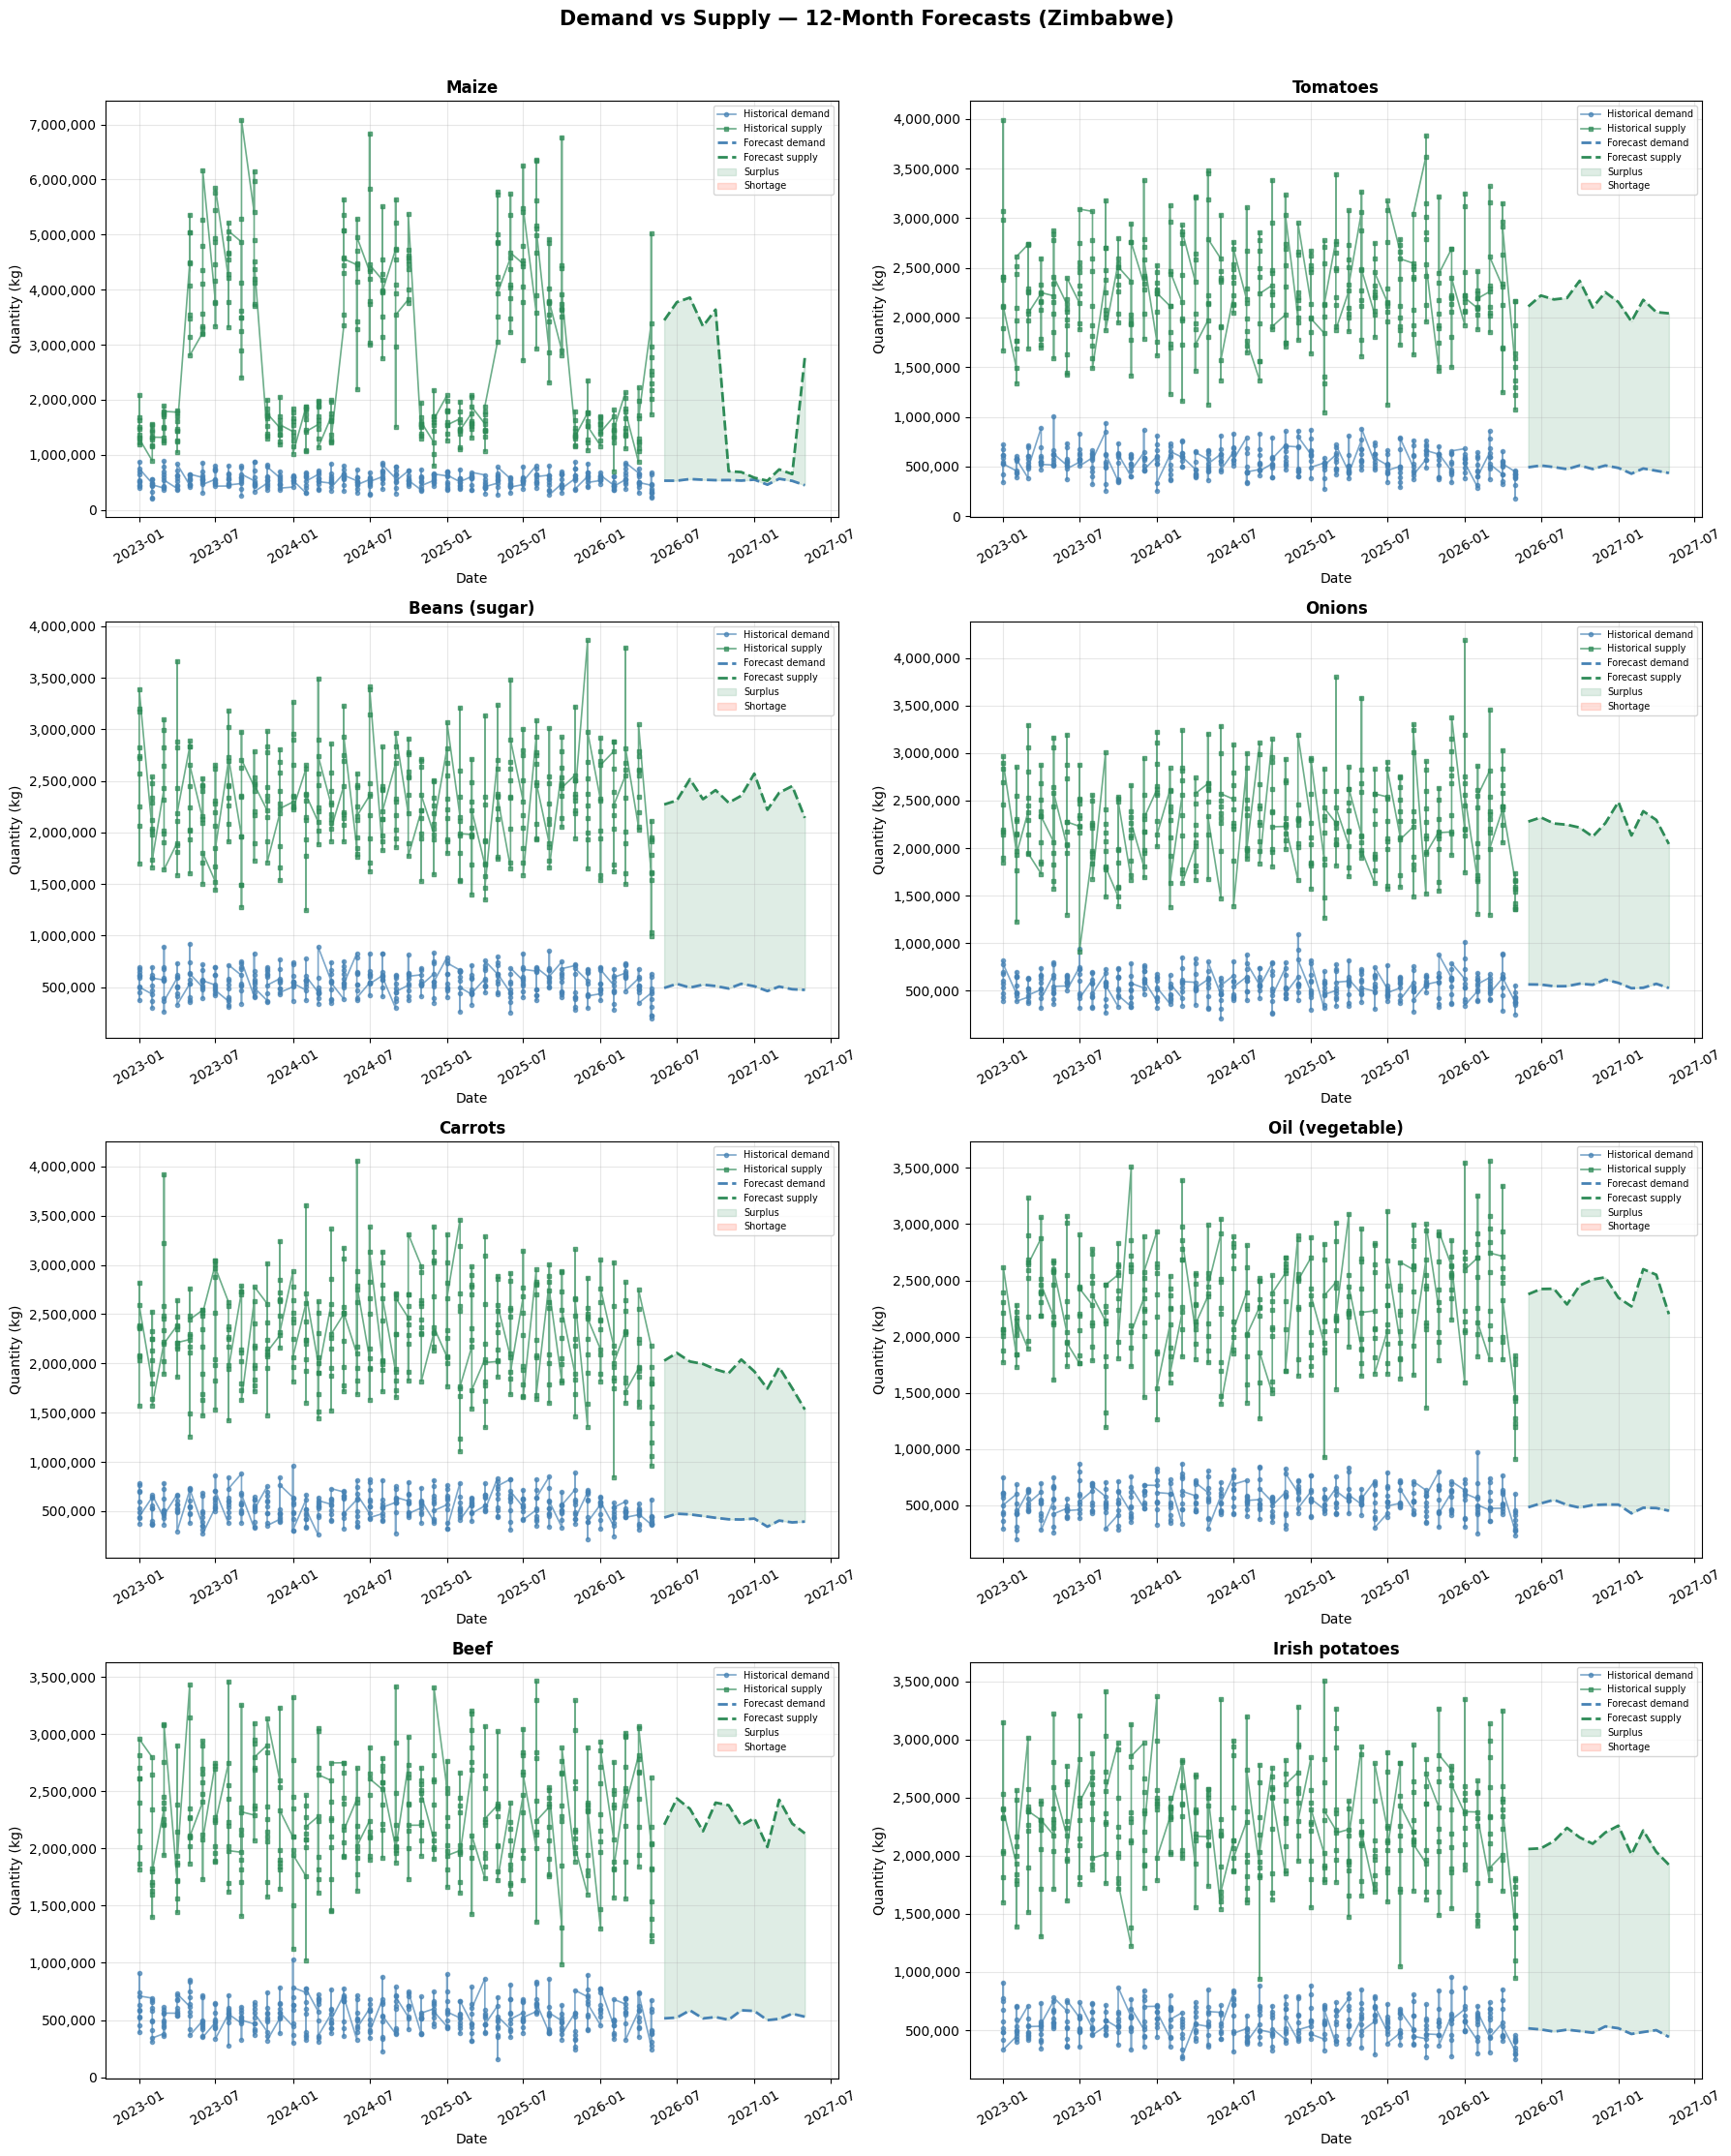

Saved → demand_supply_forecasts.png


In [15]:
# Commodities that have both demand AND supply models
plottable = sorted(set(demand_models.keys()) & set(supply_models.keys()))

PLOT_COMMODITIES = ['Maize', 'Tomatoes', 'Beans (sugar)', 'Onions',
                    'Carrots', 'Oil (vegetable)', 'Beef', 'Irish potatoes']
PLOT_COMMODITIES = [c for c in PLOT_COMMODITIES if c in plottable]
for c in plottable:
    if c not in PLOT_COMMODITIES and len(PLOT_COMMODITIES) < 8:
        PLOT_COMMODITIES.append(c)

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for i, commodity in enumerate(PLOT_COMMODITIES):
    ax  = axes[i]
    gap = forecast_gap(commodity, periods=12)

    # Historical demand
    hist_d = demand_training_data[commodity][['ds', 'y']].copy()
    hist_d = hist_d[hist_d['ds'] >= pd.Timestamp('2023-01-01')]

    # Historical supply
    hist_s = supply_training_data[commodity][['ds', 'y']].copy()
    hist_s = hist_s[hist_s['ds'] >= pd.Timestamp('2023-01-01')]

    # Plot historical
    ax.plot(hist_d['ds'], hist_d['y'], 'o-', color='steelblue',
            label='Historical demand', markersize=3, linewidth=1.2, alpha=0.7)
    ax.plot(hist_s['ds'], hist_s['y'], 's-', color='seagreen',
            label='Historical supply', markersize=3, linewidth=1.2, alpha=0.7)

    # Plot forecasts
    ax.plot(gap['ds'], gap['demand'], '--', color='steelblue',
            label='Forecast demand', linewidth=2)
    ax.plot(gap['ds'], gap['supply'], '--', color='seagreen',
            label='Forecast supply', linewidth=2)

    # Shade gap
    ax.fill_between(
        gap['ds'],
        gap['demand'],
        gap['supply'],
        where=gap['supply'] >= gap['demand'],
        alpha=0.15, color='seagreen', label='Surplus'
    )
    ax.fill_between(
        gap['ds'],
        gap['demand'],
        gap['supply'],
        where=gap['supply'] < gap['demand'],
        alpha=0.20, color='tomato', label='Shortage'
    )

    ax.set_title(commodity, fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Quantity (kg)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Demand vs Supply — 12-Month Forecasts (Zimbabwe)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('demand_supply_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → demand_supply_forecasts.png')

## Cell 13 — Gap Analysis Table
The most actionable output — shows which commodities face shortages or surpluses  
month by month so the platform can trigger alerts or sourcing actions.

In [16]:
# Run gap analysis for all commodities that have both models
all_gaps = []
for commodity in sorted(set(demand_models.keys()) & set(supply_models.keys())):
    gap = forecast_gap(commodity, periods=12)
    all_gaps.append(gap)

gap_all_df = pd.concat(all_gaps, ignore_index=True)

# Summary: worst predicted shortages (by gap_pct) across the forecast window
shortage_summary = (
    gap_all_df[gap_all_df['status'] == 'SHORTAGE']
    .groupby('commodity')['gap_pct']
    .mean()
    .sort_values()
    .reset_index()
    .rename(columns={'gap_pct': 'avg_shortage_pct'})
)

surplus_summary = (
    gap_all_df[gap_all_df['status'] == 'SURPLUS']
    .groupby('commodity')['gap_pct']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'gap_pct': 'avg_surplus_pct'})
)

print('=== PREDICTED SHORTAGES (next 12 months, national average) ===')
print(shortage_summary.to_string(index=False))

print('\n=== PREDICTED SURPLUSES ===')
print(surplus_summary.to_string(index=False))

# Full month-by-month table for a single commodity
print('\n=== Month-by-month gap — Maize — National ===')
maize_gap = forecast_gap('Maize', periods=12)
print(maize_gap[['ds', 'demand', 'supply', 'gap', 'gap_pct', 'status']].to_string(index=False))

=== PREDICTED SHORTAGES (next 12 months, national average) ===
Empty DataFrame
Columns: [commodity, avg_shortage_pct]
Index: []

=== PREDICTED SURPLUSES ===
              commodity  avg_surplus_pct
 Millet (finger millet)       494.208333
        Oil (vegetable)       395.458333
         Spinach (rape)       372.800000
          Beans (sugar)       371.508333
          Beans (round)       370.925000
                Sorghum       360.366667
                Bananas       356.750000
               Avocados       356.075000
                Carrots       355.091667
   Groundnuts (shelled)       351.766667
            Pigeon peas       350.175000
               Tomatoes       349.958333
                  Wheat       347.941667
         Fish (kapenta)       343.900000
                 Barley       337.216667
                Mangoes       331.908333
         Irish potatoes       328.483333
             Butternuts       326.325000
                   Beef       324.708333
                  Sugar

## Cell 14 — End-to-End From Disk (Production Simulation)

In [17]:
# Load exactly as app/state.py will at startup
ld_demand_models   = joblib.load('demand_models.pkl')
ld_demand_features = joblib.load('demand_features.pkl')
ld_supply_models   = joblib.load('supply_models.pkl')
ld_supply_features = joblib.load('supply_features.pkl')
ld_demand_list     = joblib.load('demand_commodity_list.pkl')
ld_supply_list     = joblib.load('supply_commodity_list.pkl')

print(f'Loaded {len(ld_demand_models)} demand models from disk.')
print(f'Loaded {len(ld_supply_models)} supply models from disk.')

def _disk_forecast(commodity_name, models_dict, features_dict, region=None, periods=12):
    if commodity_name not in models_dict:
        raise ValueError(f"'{commodity_name}' not in models.")
    model  = models_dict[commodity_name]
    cols   = features_dict[commodity_name]
    future = model.make_future_dataframe(periods=periods, freq='MS')
    if cols:
        for col in cols: future[col] = 0
        if region:
            rc = f'region_{region}'
            if rc not in cols: raise ValueError(f"Region '{region}' not recognised.")
            future[rc] = 1
    fc = model.predict(future)
    r  = fc[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods).copy()
    r[['yhat','yhat_lower','yhat_upper']] = r[['yhat','yhat_lower','yhat_upper']].clip(lower=0).round(1)
    r['commodity'] = commodity_name
    r['region']    = region or 'National'
    return r.reset_index(drop=True)

# Quick test
test_commodity = ld_demand_list[0]

d_test = _disk_forecast(test_commodity, ld_demand_models, ld_demand_features, periods=3)
s_test = _disk_forecast(test_commodity, ld_supply_models, ld_supply_features, periods=3)

print(f'\nDemand forecast — {test_commodity} (first 3 months):')
print(d_test.to_string(index=False))

print(f'\nSupply forecast — {test_commodity} (first 3 months):')
print(s_test.to_string(index=False))

print('\n✅ End-to-end inference from disk confirmed.')

Loaded 39 demand models from disk.
Loaded 39 supply models from disk.

Demand forecast — Avocados (first 3 months):
        ds     yhat  yhat_lower  yhat_upper commodity   region
2026-06-01 506339.4    346100.5    663206.0  Avocados National
2026-07-01 520136.2    346474.2    683554.6  Avocados National
2026-08-01 534569.5    368216.4    704937.7  Avocados National

Supply forecast — Avocados (first 3 months):
        ds      yhat  yhat_lower  yhat_upper commodity   region
2026-06-01 2121871.4   1555592.2   2717650.5  Avocados National
2026-07-01 2243012.6   1665725.8   2835196.6  Avocados National
2026-08-01 2456193.7   1880933.4   3089307.3  Avocados National

✅ End-to-end inference from disk confirmed.
